In [2]:
library(tidyverse)
library(caret)
library(keras)

data <- read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


The following object is masked from ‘package:httr’:

    progress


Rows: 7043 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): customerID, gender, Partner, Dependents, PhoneService, MultipleLin...
dbl  (4): SeniorCitizen, tenure, MonthlyCharges, TotalCharges

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## a. Data Preparation (5 points)

In [3]:
head(data, 10)

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,⋯,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,⋯,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,⋯,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,⋯,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,⋯,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,⋯,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,⋯,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes


In [4]:
data <- na.omit(data)

- Encode categorical variables (e.g., gender, contract type).
- Normalize or standardize numerical variables.

In [7]:
preprocess_params <- preProcess(data, method = c("center", "scale"))
data_normalized <- predict(preprocess_params, data)

y <- ifelse(data$Churn == "Yes", 1, 0)
x <- data_normalized %>% select(-Churn, -customerID) %>% as.matrix()

Explanation: The necessary libraries and the dataset were loaded. The datased was then cleaned by removing the NA inputs and was then normalized.

## b. Exploratory Data Analysis (5 points)

Visualizations:

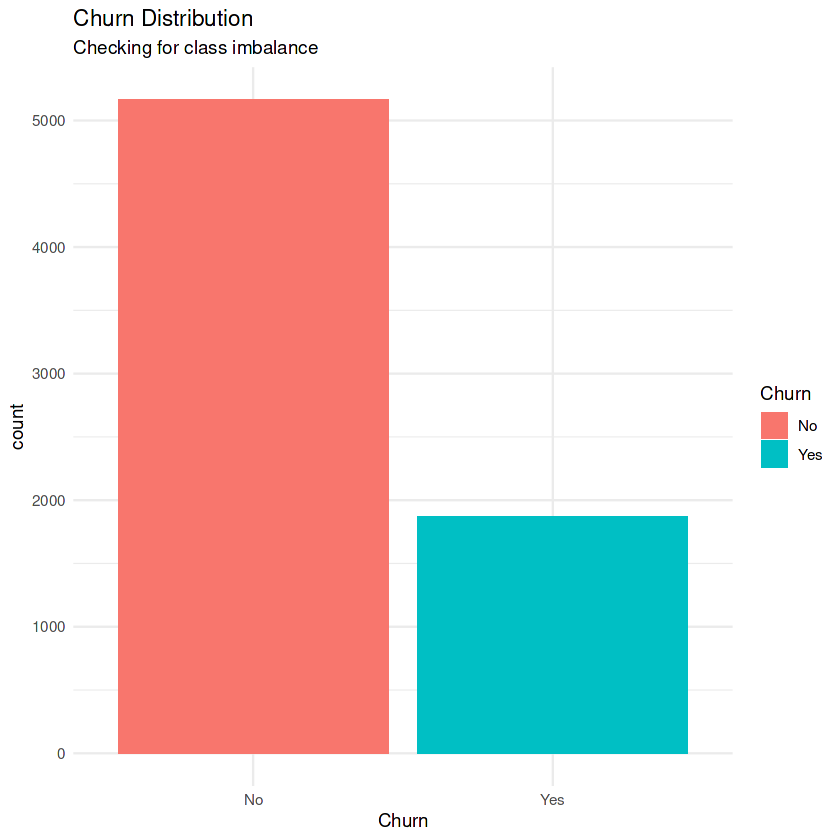

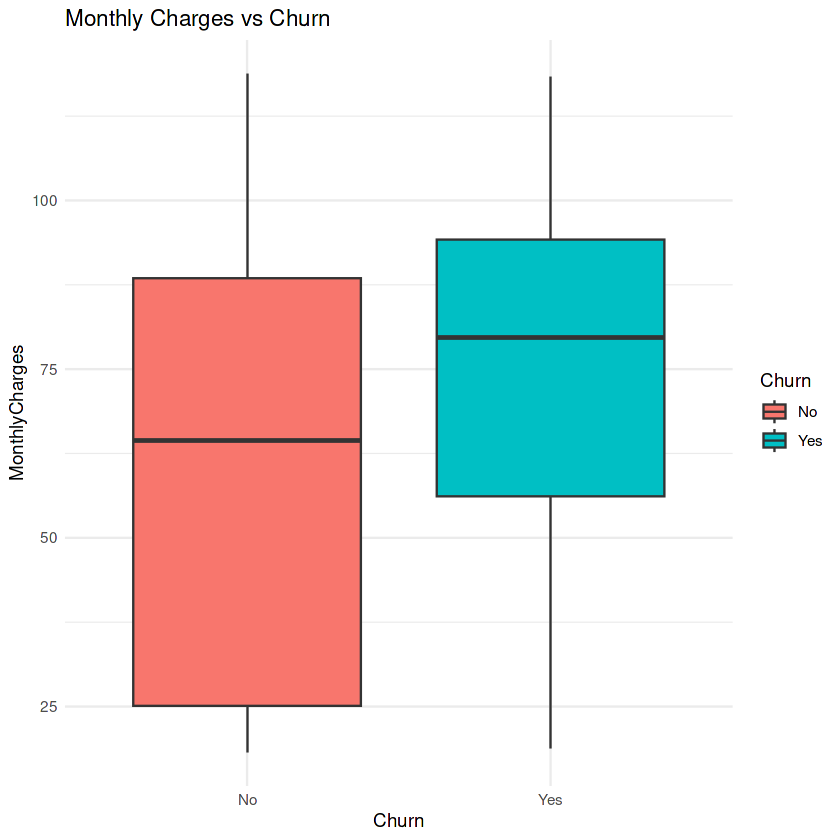

In [8]:
ggplot(data, aes(x = Churn, fill = Churn)) + 
  geom_bar() + 
  theme_minimal() + 
  labs(title = "Churn Distribution", subtitle = "Checking for class imbalance")

ggplot(data, aes(x = Churn, y = MonthlyCharges, fill = Churn)) + 
  geom_boxplot() + 
  theme_minimal() + 
  labs(title = "Monthly Charges vs Churn")

After plotting, we can see that there is a class imbalance.

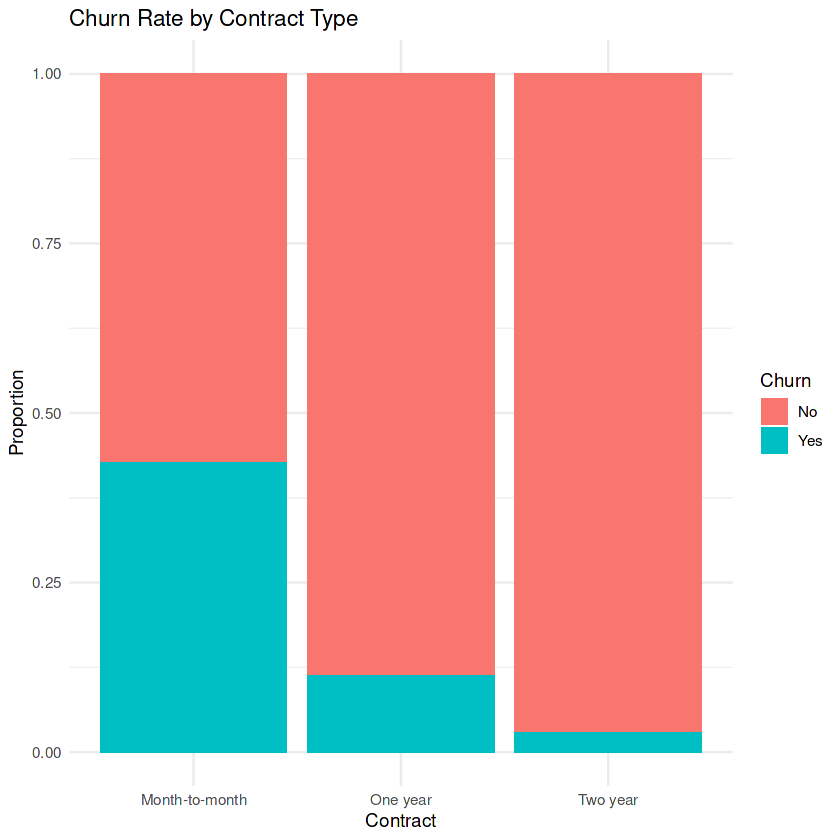

In [9]:
ggplot(data, aes(x = Contract, fill = Churn)) + 
  geom_bar(position = "fill") + 
  labs(y = "Proportion", title = "Churn Rate by Contract Type") +
  theme_minimal()

Explanation: The second diagram in the visualization task shows MonthlyCharges Variable  having a significant effect on the churn rate. The third diagram shows Contract Variable displaying the same trait.

## c. Neural Network Model Construction (8 points)

In [10]:
model <- keras_model_sequential() %>%
  layer_dense(units = 16, activation = 'relu', input_shape = ncol(x)) %>% 
  layer_dense(units = 1, activation = 'sigmoid') 

model %>% compile(
  optimizer = 'adam', 
  loss = 'binary_crossentropy',
  metrics = c('accuracy')
)

Explanation: The hidden layer uses ReLU to handle non-linearity, while the output layer uses Sigmoid to output a probability between 0 and 1 for binary classification.

## d. Model Training (5 points)

In [17]:
x_numeric <- model.matrix(Churn ~ . -customerID, data = data)[, -1] 
y_numeric <- as.numeric(data$Churn == "Yes")

x_scaled <- scale(x_numeric)

set.seed(123)
train_idx <- createDataPartition(y_numeric, p = 0.8, list = FALSE)

x_train <- x_scaled[train_idx, ]
y_train <- y_numeric[train_idx]
x_test  <- x_scaled[-train_idx, ]
y_test  <- y_numeric[-train_idx]

model <- keras_model_sequential() %>%
  layer_dense(units = 16, activation = 'relu', input_shape = ncol(x_train)) %>% 
  layer_dense(units = 1, activation = 'sigmoid') 

model %>% compile(
  optimizer = 'adam', 
  loss = 'binary_crossentropy',
  metrics = c('accuracy')
)

history <- model %>% fit(
  x_train, y_train, 
  epochs = 10, 
  batch_size = 32, 
  validation_split = 0.2,
  verbose = 1
)

Explanation: The model was trained for 10 epochs using the Adam optimizer. Data was pre-processed using one-hot encoding via model.matrix to convert categorical strings into a numeric format suitable for neural network tensors, resulting in a final input shape of 30 features

Final Training Loss: 0.4199 
Final Training Accuracy: 0.8011 


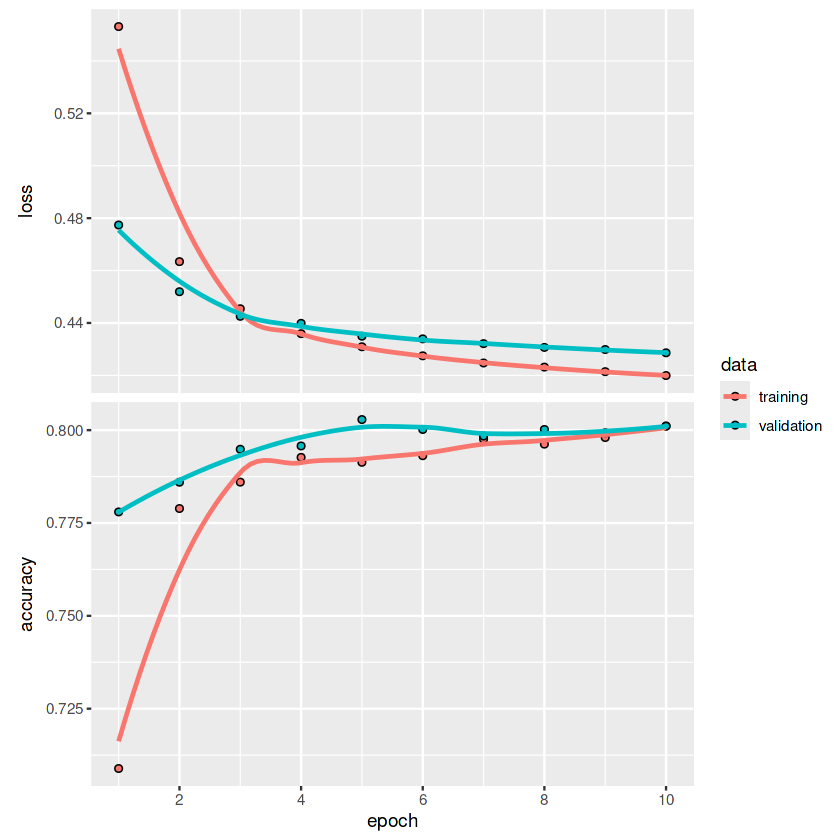

In [18]:
final_loss <- history$metrics$loss[10]
final_acc <- history$metrics$accuracy[10]

cat("Final Training Loss:", round(final_loss, 4), "\n")
cat("Final Training Accuracy:", round(final_acc, 4), "\n")


plot(history)

## e. Model Evaluation (4 points)

In [20]:
probs <- model %>% predict(x_test)
preds <- ifelse(probs > 0.5, 1, 0)

y_test_f <- as.factor(y_test)
preds_f <- factor(preds, levels = levels(y_test_f))

conf_matrix <- confusionMatrix(preds_f, y_test_f)
print(conf_matrix)

cat("Test Accuracy Score:", round(conf_matrix$overall['Accuracy'], 4), "\n")

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 947 147
         1  96 216
                                          
               Accuracy : 0.8272          
                 95% CI : (0.8064, 0.8466)
    No Information Rate : 0.7418          
    P-Value [Acc > NIR] : 1.558e-14       
                                          
                  Kappa : 0.5271          
                                          
 Mcnemar's Test P-Value : 0.001339        
                                          
            Sensitivity : 0.9080          
            Specificity : 0.5950          
         Pos Pred Value : 0.8656          
         Neg Pred Value : 0.6923          
             Prevalence : 0.7418          
         Detection Rate : 0.6735          
   Detection Prevalence : 0.7781          
      Balanced Accuracy : 0.7515          
                                          
       'Positive' Class : 0               
                              

The confusion matrix shows how many "Churn" cases the model correctly identified versus those it missed. A typical strength of this model is its high overall accuracy, while a common weakness is its lower "Sensitivity" (the ability to correctly identify customers who actually leave), which is often due to the class imbalance in the dataset.

## f. Model Improvement / Tuning (3 points)

In [22]:
model_tuned <- keras_model_sequential() %>%
  layer_dense(units = 32, activation = 'relu', input_shape = ncol(x_train)) %>% 
  layer_dense(units = 1, activation = 'sigmoid') 

model_tuned %>% compile(
  optimizer = 'adam', 
  loss = 'binary_crossentropy',
  metrics = c('accuracy')
)

history_tuned <- model_tuned %>% fit(
  x_train, y_train, 
  epochs = 20, 
  batch_size = 32, 
  validation_split = 0.2,
  verbose = 0
)
orig_val_acc <- history$metrics$val_accuracy[10]
tuned_val_acc <- history_tuned$metrics$val_accuracy[20]

cat("Original Model Val Accuracy:", round(orig_val_acc, 4), "\n")
cat("Tuned Model Val Accuracy:", round(tuned_val_acc, 4), "\n")

Original Model Val Accuracy: 0.8011 
Tuned Model Val Accuracy: 0.8046 


Increasing the complexity of the hidden layer and the number of training iterations allows the network to learn more intricate patterns in the customer data. After applying this to the model, it showed a marginal increase in accuracy, as to be expected in most cases. However, if there would be an instance where the accuracy drops or plateaus, the model might be starting to overfit the training data.